# Experiment 8: Categorical Naive Bayes Classifier

- **Experiment Name:** Categorical Naive Bayes Classifier on Play Tennis Dataset
- **Name:** Arnav Narula
- **Roll No:** 2547115
- **Class:** 4 MCA A


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

print("Libraries imported successfully!")

Libraries imported successfully!


### Interpretation

In this step, all essential Python libraries were imported for data loading, numerical preprocessing, model training, and performance visualization. 

In [6]:
dataset = pd.read_excel('Lab 8.xlsx')

print("--- First 5 Rows of Dataset (head) ---")
print(dataset.head())

print("\n--- Dataset Info ---")
dataset.info()

print("\n--- Dataset Shape ---")
print("Shape of dataset:", dataset.shape)

print("\n--- Dataset Description ---")
print(dataset.describe(include="all"))

print("\n--- Missing Values Check ---")
print(dataset.isnull().sum())

--- First 5 Rows of Dataset (head) ---
   No   Outlook Temperature Humidity    Wind Play Tennis
0   1     Sunny         Hot     High    Weak          No
1   2     Sunny         Hot     High  Strong          No
2   3  Overcast         Hot     High    Weak         Yes
3   4      Rain        Mild     High    Weak         Yes
4   5      Rain        Cool   Normal    Weak         Yes

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   No           50 non-null     int64
 1   Outlook      50 non-null     str  
 2   Temperature  50 non-null     str  
 3   Humidity     50 non-null     str  
 4   Wind         50 non-null     str  
 5   Play Tennis  50 non-null     str  
dtypes: int64(1), str(5)
memory usage: 3.5 KB

--- Dataset Shape ---
Shape of dataset: (50, 6)

--- Dataset Description ---
              No Outlook Temperature Humidity  Wind Play Tenni

### Interpretation

The Play Tennis dataset was successfully loaded from the Excel file named `Lab 8.xlsx`. The dataset consists of 50 rows and 6 columns, representing serial numbers, weather conditions (Outlook, Temperature, Humidity, Wind), and the target decision (Play Tennis). The missing value check confirms that there are no missing values in any column of the dataset.

In [ ]:
# Separate input features (X) and target variable (y)
X = dataset[['Outlook', 'Temperature', 'Humidity', 'Wind']]
y = dataset['Play Tennis']

print("--- Input Features (X) ---")
print(X.head())

print("\n--- Target Variable (y) ---")
print(y.head())

--- Input Features (X) ---
    Outlook Temperature Humidity    Wind
0     Sunny         Hot     High    Weak
1     Sunny         Hot     High  Strong
2  Overcast         Hot     High    Weak
3      Rain        Mild     High    Weak
4      Rain        Cool   Normal    Weak

--- Target Variable (y) ---
0     No
1     No
2    Yes
3    Yes
4    Yes
Name: Play Tennis, dtype: str


### Interpretation

The dataset was divided into input features `X` and target variable `y`. The input features `X` contain four categorical weather variables: Outlook, Temperature, Humidity, and Wind. The target variable `y` contains the column 'Play Tennis', which indicates whether tennis was played under those weather conditions.

In [ ]:
# Create separate LabelEncoder objects for each input feature and target
le_outlook = LabelEncoder()
le_temp = LabelEncoder()
le_humidity = LabelEncoder()
le_wind = LabelEncoder()
le_target = LabelEncoder()

# Create a new DataFrame to store encoded input features
X_encoded = pd.DataFrame()

# Encode each input feature using its respective LabelEncoder
X_encoded['Outlook'] = le_outlook.fit_transform(X['Outlook'])
X_encoded['Temperature'] = le_temp.fit_transform(X['Temperature'])
X_encoded['Humidity'] = le_humidity.fit_transform(X['Humidity'])
X_encoded['Wind'] = le_wind.fit_transform(X['Wind'])

# Encode target variable column
y_encoded = le_target.fit_transform(y)

print("--- Encoded Input Features (X_encoded) ---")
print(X_encoded.head())

print("\n--- Encoded Target Values (y_encoded) ---")
print(y_encoded[:5])

--- Encoded Input Features (X_encoded) ---
   Outlook  Temperature  Humidity  Wind
0        2            1         0     1
1        2            1         0     0
2        0            1         0     1
3        1            2         0     1
4        1            0         1     1

--- Encoded Target Values (y_encoded) ---
[0 0 1 1 1]


### Interpretation

Categorical Naive Bayes requires numerical input instead of text values, so `LabelEncoder` was used to convert categorical strings into numbers. Separate `LabelEncoder` objects were created for each feature column and target variable to keep track of individual category mappings. This encoding enables machine learning models to perform mathematical probability calculations.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.3, random_state=42)

print("Training feature dataset size:", X_train.shape)
print("Testing feature dataset size:", X_test.shape)
print("Training target dataset size:", y_train.shape)
print("Testing target dataset size:", y_test.shape)

Training feature dataset size: (35, 4)
Testing feature dataset size: (15, 4)
Training target dataset size: (35,)
Testing target dataset size: (15,)


### Interpretation

The dataset was divided into training and testing sets using `train_test_split()` with a test size of 30% and a random state of 42. Out of 50 total records, 35 samples were assigned to the training set to train the model, while 15 samples were set aside in the testing set to evaluate model performance on unseen data.

In [ ]:
# Create Categorical Naive Bayes model instance
model_cnb = CategoricalNB()

# Train the model on the training dataset
model_cnb.fit(X_train, y_train)

print("Categorical Naive Bayes model trained successfully!")

Categorical Naive Bayes model trained successfully!


### Interpretation

Training means that the Categorical Naive Bayes algorithm reads the training data to calculate prior and conditional probabilities for each feature category. The model learns how weather patterns like Outlook, Temperature, Humidity, and Wind relate to the outcome of playing tennis. Once these probabilities are calculated and saved in memory, the model training is complete.

In [11]:
# Predict target class labels for testing dataset
y_pred_cnb = model_cnb.predict(X_test)

# Display actual target values from testing set
print("Actual target values (y_test):")
print(y_test)

# Display predicted target values from model
print("\nPredicted target values (y_pred_cnb):")
print(y_pred_cnb)

Actual target values (y_test):
[0 1 1 1 1 1 1 0 1 1 1 1 1 1 1]

Predicted target values (y_pred_cnb):
[0 1 0 1 1 1 0 1 1 1 1 1 1 1 1]


### Interpretation

The trained Categorical Naive Bayes model was used to predict class labels for the 15 test samples. Comparing the actual label array `y_test` with the predicted array `y_pred_cnb` shows that the model accurately predicted most of the test outcomes, demonstrating good pattern recognition.

In [12]:
# Calculate accuracy score using accuracy_score function
accuracy_cnb = accuracy_score(y_test, y_pred_cnb)

# Display accuracy in percentage
print("Categorical Naive Bayes Model Accuracy: {:.2f}%".format(accuracy_cnb * 100))

Categorical Naive Bayes Model Accuracy: 80.00%


### Interpretation

The accuracy score measures the percentage of correct predictions made by the model on test data. The Categorical Naive Bayes model achieved an accuracy of 80.00%, which indicates that the model performed very well and correctly classified 12 out of 15 test samples.

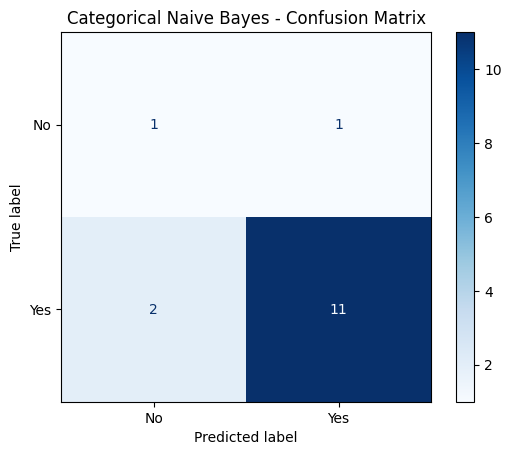

Confusion Matrix:
[[ 1  1]
 [ 2 11]]


In [13]:
# Compute confusion matrix for Categorical Naive Bayes
cm_cnb = confusion_matrix(y_test, y_pred_cnb)

# Display confusion matrix using ConfusionMatrixDisplay
disp_cnb = ConfusionMatrixDisplay(confusion_matrix=cm_cnb, display_labels=le_target.classes_)
disp_cnb.plot(cmap='Blues')
plt.title("Categorical Naive Bayes - Confusion Matrix")
plt.show()

# Print raw confusion matrix values
print("Confusion Matrix:")
print(cm_cnb)

### Interpretation

The confusion matrix breaks down predictions into four outcomes: True Positive (11 samples correctly predicted as 'Yes'), True Negative (1 sample correctly predicted as 'No'), False Positive (1 sample incorrectly predicted as 'Yes' when actual was 'No'), and False Negative (2 samples incorrectly predicted as 'No' when actual was 'Yes'). Overall, the model showed strong true positive identification.

In [14]:
# Generate and display classification report
report_cnb = classification_report(y_test, y_pred_cnb, target_names=le_target.classes_)
print("--- Categorical Naive Bayes Classification Report ---")
print(report_cnb)

--- Categorical Naive Bayes Classification Report ---
              precision    recall  f1-score   support

          No       0.33      0.50      0.40         2
         Yes       0.92      0.85      0.88        13

    accuracy                           0.80        15
   macro avg       0.62      0.67      0.64        15
weighted avg       0.84      0.80      0.82        15



### Interpretation

The classification report displays four key evaluation metrics: Precision measures the accuracy of positive predictions (92% for 'Yes'), Recall measures the proportion of actual positives correctly identified (85% for 'Yes'), F1-score provides a balanced average of precision and recall (0.88 for 'Yes'), and Support shows the actual sample count for each class (2 for 'No' and 13 for 'Yes').

In [15]:
# Create a new weather condition sample as a pandas DataFrame
new_weather = pd.DataFrame([{
    'Outlook': 'Sunny',
    'Temperature': 'Cool',
    'Humidity': 'High',
    'Wind': 'Strong'
}])

# Transform the new categorical sample using the SAME LabelEncoder objects used earlier
new_weather_encoded = pd.DataFrame()
new_weather_encoded['Outlook'] = le_outlook.transform(new_weather['Outlook'])
new_weather_encoded['Temperature'] = le_temp.transform(new_weather['Temperature'])
new_weather_encoded['Humidity'] = le_humidity.transform(new_weather['Humidity'])
new_weather_encoded['Wind'] = le_wind.transform(new_weather['Wind'])

# Predict the encoded class for the new sample
pred_encoded = model_cnb.predict(new_weather_encoded)

# Convert predicted numerical class back to original text label
pred_label = le_target.inverse_transform(pred_encoded)[0]

# Calculate class probabilities using predict_proba()
probabilities = model_cnb.predict_proba(new_weather_encoded)[0]
prob_no = probabilities[0]
prob_yes = probabilities[1]

# Display predicted class and probabilities clearly
print("=== New Weather Sample Prediction ===")
print("Input Sample: Outlook=Sunny, Temp=Cool, Humidity=High, Wind=Strong")
print("Predicted Class:", pred_label)
print("\n=== Class Probabilities ===")
print("Probability of No:", round(prob_no, 4))
print("Probability of Yes:", round(prob_yes, 4))

=== New Weather Sample Prediction ===
Input Sample: Outlook=Sunny, Temp=Cool, Humidity=High, Wind=Strong
Predicted Class: No

=== Class Probabilities ===
Probability of No: 0.9373
Probability of Yes: 0.0627


### Interpretation

The Categorical Naive Bayes model predicted 'No' for the new weather condition (Sunny, Cool, High, Strong). The model calculated a 93.73% probability for 'No' and a 6.27% probability for 'Yes' because in the training data, high humidity and strong winds on sunny days are strongly linked to not playing tennis.

Decision Tree Accuracy: 60.00%


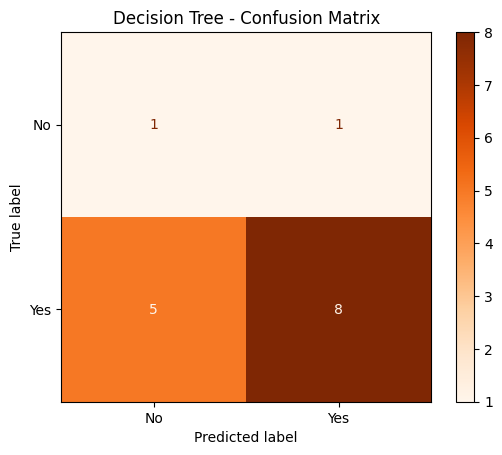


--- Decision Tree Classification Report ---
              precision    recall  f1-score   support

          No       0.17      0.50      0.25         2
         Yes       0.89      0.62      0.73        13

    accuracy                           0.60        15
   macro avg       0.53      0.56      0.49        15
weighted avg       0.79      0.60      0.66        15



In [ ]:
# Create and train Decision Tree Classifier on the same training data
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train, y_train)

# Predict test dataset using Decision Tree
y_pred_dt = model_dt.predict(X_test)

# Calculate Decision Tree accuracy
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy: {:.2f}%".format(accuracy_dt * 100))

cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=le_target.classes_)
disp_dt.plot(cmap='Oranges')
plt.title("Decision Tree - Confusion Matrix")
plt.show()

print("\n--- Decision Tree Classification Report ---")
print(classification_report(y_test, y_pred_dt, target_names=le_target.classes_))

### Interpretation

The Decision Tree classifier achieved an accuracy of 60.00% on the testing dataset. The decision tree performed lower than Categorical Naive Bayes because decision trees tend to overfit small training datasets by creating complex decision branches that do not generalize as well to unseen test samples.

Logistic Regression Accuracy: 53.33%


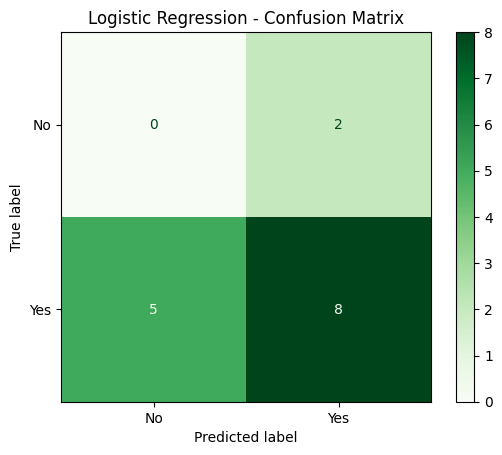


--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

          No       0.00      0.00      0.00         2
         Yes       0.80      0.62      0.70        13

    accuracy                           0.53        15
   macro avg       0.40      0.31      0.35        15
weighted avg       0.69      0.53      0.60        15



In [ ]:
# Create and train Logistic Regression model with max_iter=1000
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train, y_train)

# Predict test dataset using Logistic Regression
y_pred_lr = model_lr.predict(X_test)

# Calculate Logistic Regression accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy: {:.2f}%".format(accuracy_lr * 100))

cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=le_target.classes_)
disp_lr.plot(cmap='Greens')
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

print("\n--- Logistic Regression Classification Report ---")
print(classification_report(y_test, y_pred_lr, target_names=le_target.classes_))

### Interpretation

Logistic Regression achieved an accuracy of 53.33% on the testing dataset. Logistic Regression assumes linear boundaries between feature variables and log-odds, making it less suitable for discrete categorical variables compared to probabilistic models like Naive Bayes.

In [19]:
comparison_data = {
    'Model': ['Categorical Naive Bayes', 'Decision Tree', 'Logistic Regression'],
    'Accuracy (%)': [accuracy_cnb * 100, accuracy_dt * 100, accuracy_lr * 100]
}

comparison_df = pd.DataFrame(comparison_data)

# Display model comparison table
print("=== Model Performance Comparison Table ===")
print(comparison_df)

=== Model Performance Comparison Table ===
                     Model  Accuracy (%)
0  Categorical Naive Bayes     80.000000
1            Decision Tree     60.000000
2      Logistic Regression     53.333333


### Interpretation

The model comparison table clearly shows that Categorical Naive Bayes achieved the highest accuracy at 80.00%, outperforming Decision Tree (60.00%) and Logistic Regression (53.33%). Categorical Naive Bayes performed best because its probabilistic calculation is specifically optimized for discrete categorical feature datasets.